# ML System Design
Patterns and principles for designing production ML systems.
Prerequisites: `pip install numpy matplotlib pandas`

📺 **Video Lecture:** [https://youtu.be/7bjOx8U1AyY](https://youtu.be/7bjOx8U1AyY)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
np.random.seed(42)

## 1. System Design Framework
A structured approach: Requirements → Data → Model → Serving → Monitoring

In [3]:
framework = {
    'Step': ['1. Clarify Requirements', '2. Data Pipeline', '3. Feature Engineering',
             '4. Model Selection', '5. Training Pipeline', '6. Serving Architecture',
             '7. Monitoring & Feedback'],
    'Key Questions': [
        'Latency? Throughput? Accuracy vs speed tradeoff?',
        'Data sources? Volume? Freshness? Quality?',
        'Real-time vs batch? Feature store?',
        'Complexity vs interpretability? Baseline first!',
        'Online vs offline? Distributed?',
        'Batch vs real-time? Caching? Load balancing?',
        'Drift detection? A/B testing? Logging?',
    ]
}
print(pd.DataFrame(framework).to_string(index=False))

                    Step                                    Key Questions
 1. Clarify Requirements Latency? Throughput? Accuracy vs speed tradeoff?
        2. Data Pipeline        Data sources? Volume? Freshness? Quality?
  3. Feature Engineering               Real-time vs batch? Feature store?
      4. Model Selection  Complexity vs interpretability? Baseline first!
    5. Training Pipeline                  Online vs offline? Distributed?
 6. Serving Architecture     Batch vs real-time? Caching? Load balancing?
7. Monitoring & Feedback           Drift detection? A/B testing? Logging?


## 2. Latency vs Throughput Analysis

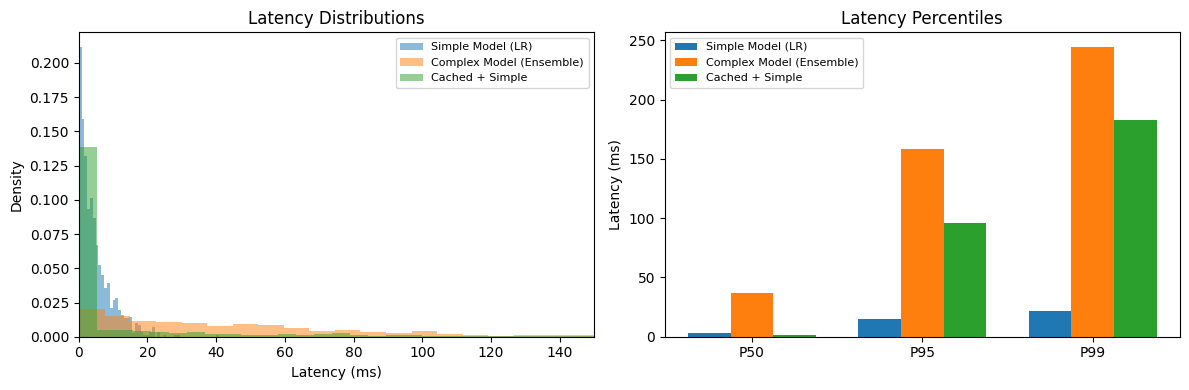

In [4]:
# Simulate latency distributions for different serving strategies
np.random.seed(42)
latencies = {
    'Simple Model (LR)': np.random.exponential(5, 1000),
    'Complex Model (Ensemble)': np.random.exponential(50, 1000),
    'Cached + Simple': np.concatenate([np.random.exponential(1, 700),  # cache hit
                                       np.random.exponential(50, 300)]), # cache miss
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, lat in latencies.items():
    axes[0].hist(lat, bins=50, alpha=0.5, label=name, density=True)
axes[0].set_xlabel('Latency (ms)'); axes[0].set_ylabel('Density')
axes[0].set_title('Latency Distributions'); axes[0].legend(fontsize=8)
axes[0].set_xlim(0, 150)

# P50, P95, P99 comparison
percentiles = {}
for name, lat in latencies.items():
    percentiles[name] = [np.percentile(lat, p) for p in [50, 95, 99]]

x = np.arange(3)
width = 0.25
for i, (name, vals) in enumerate(percentiles.items()):
    axes[1].bar(x + i*width, vals, width, label=name)
axes[1].set_xticks(x + width); axes[1].set_xticklabels(['P50', 'P95', 'P99'])
axes[1].set_ylabel('Latency (ms)'); axes[1].set_title('Latency Percentiles')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Feature Store Pattern

In [5]:
class SimpleFeatureStore:
    """Demonstrates the feature store concept."""
    def __init__(self):
        self.offline_store = {}  # for training (batch)
        self.online_store = {}   # for serving (low-latency)
    
    def ingest(self, entity_id, features, timestamp):
        key = entity_id
        self.offline_store.setdefault(key, []).append(
            {'features': features, 'timestamp': timestamp}
        )
        self.online_store[key] = features  # latest only
    
    def get_training_data(self, entity_ids):
        return {eid: self.offline_store.get(eid, []) for eid in entity_ids}
    
    def get_online_features(self, entity_id):
        return self.online_store.get(entity_id, {})

fs = SimpleFeatureStore()
# Ingest user features over time
for day in range(5):
    fs.ingest('user_123', {'login_count': 10+day, 'avg_session': 25.0+day*2}, f'2024-01-0{day+1}')

print('Online features (latest):', fs.get_online_features('user_123'))
print(f'Offline store: {len(fs.get_training_data(["user_123"])["user_123"])} historical records')

Online features (latest): {'login_count': 14, 'avg_session': 33.0}
Offline store: 5 historical records


## 4. Batch vs Real-Time Serving

In [6]:
# Compare batch prediction vs real-time serving
scenarios = pd.DataFrame({
    'Use Case': ['Email spam filter', 'Product recommendations', 'Fraud detection',
                 'Search ranking', 'Churn prediction', 'Ad click prediction'],
    'Serving Mode': ['Real-time', 'Batch + Cache', 'Real-time',
                     'Real-time', 'Batch', 'Real-time'],
    'Latency Req': ['<100ms', '<200ms', '<50ms', '<100ms', 'Hours OK', '<10ms'],
    'Why': ['Per-message decision', 'Pre-compute for catalog', 'Immediate block needed',
            'Per-query ranking', 'Daily batch job', 'Per-impression bidding'],
})
print(scenarios.to_string(index=False))

               Use Case  Serving Mode Latency Req                     Why
      Email spam filter     Real-time      <100ms    Per-message decision
Product recommendations Batch + Cache      <200ms Pre-compute for catalog
        Fraud detection     Real-time       <50ms  Immediate block needed
         Search ranking     Real-time      <100ms       Per-query ranking
       Churn prediction         Batch    Hours OK         Daily batch job
    Ad click prediction     Real-time       <10ms  Per-impression bidding


## 5. Scaling: Horizontal vs Vertical

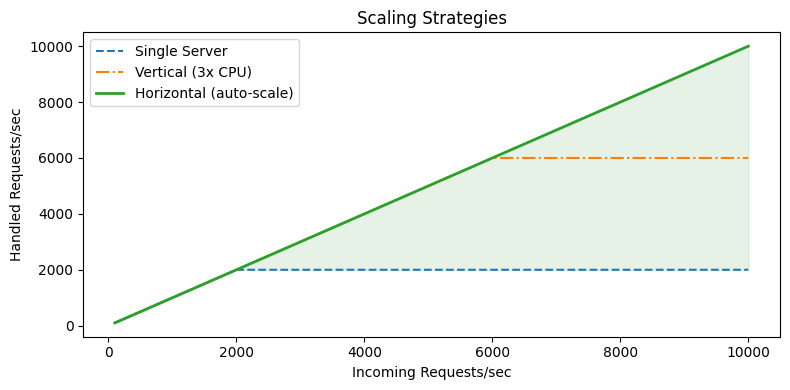

In [7]:
# Simulate throughput with different scaling strategies
n_requests = np.arange(100, 10001, 100)
single_server_cap = 2000

# Single server: throughput caps out
single = np.minimum(n_requests, single_server_cap)
# Vertical scaling: bigger server
vertical = np.minimum(n_requests, single_server_cap * 3)
# Horizontal scaling: add servers
horizontal = n_requests  # scales linearly (ideal)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_requests, single, label='Single Server', linestyle='--')
ax.plot(n_requests, vertical, label='Vertical (3x CPU)', linestyle='-.')
ax.plot(n_requests, horizontal, label='Horizontal (auto-scale)', linewidth=2)
ax.fill_between(n_requests, single, horizontal, alpha=0.1, color='green')
ax.set_xlabel('Incoming Requests/sec'); ax.set_ylabel('Handled Requests/sec')
ax.set_title('Scaling Strategies'); ax.legend(); plt.tight_layout(); plt.show()

## 6. Interview Takeaways
- Always start with **requirements**: latency, throughput, accuracy tradeoffs
- Start with a **simple baseline** before complex models
- **Feature store** separates feature computation from model training/serving
- Choose **batch vs real-time** serving based on latency needs
- **Caching** can dramatically reduce serving latency
- Monitor **data drift**, model performance, and system health
- Design for **horizontal scaling** when possible

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>